# Gaussian mixtures with splat-inspired refinement

A feasibility experiment for tabular simulation in Trex. Gaussian blobs can
approximate a distribution in feature space just as they can approximate image
content, but the probability model is different from an image renderer.

**Main conclusion:** normalized Gaussian components are a useful lightweight
baseline. This pilot does not establish an advantage of gradient-based
split/refine training over ordinary EM, nor a general ranking of mixture,
adversarial, and diffusion generators.

## Probability model

For a $d$-column continuous row $x$, the model is

$$p_\theta(x)=\sum_{k=1}^{K}\pi_k\,
\frac{\exp\{-\tfrac12(x-\mu_k)'\Sigma_k^{-1}(x-\mu_k)\}}
{(2\pi)^{d/2}|\Sigma_k|^{1/2}},\qquad
\pi_k=\frac{\exp(a_k)}{\sum_j\exp(a_j)}.$$

Unlike image splatting, there is no colour, opacity compositing, or front-to-back
ordering. Each Gaussian integrates to one and its mass is $\pi_k$. This is an
ordinary **Gaussian mixture family**. The experimental part is growing and
refining the representation, not a new family of probability distributions.

Covariances are parameterized as $\Sigma_k=L_kL_k'+\epsilon I$, where $L_k$ is
lower triangular with positive diagonal and $\epsilon=0.0025$ in transformed
units. The floor prevents components shrinking to point masses to make the
training likelihood unbounded. Fitting minimizes

$$\mathcal L(\theta)=-\frac1n\sum_{i=1}^n\log p_\theta(x_i).$$

The code evaluates the sum in log space and differentiates through the
covariance factors. To sample a row, draw $k\sim\mathrm{Categorical}(\pi)$,
then $x=\mu_k+C_k z$, with $C_kC_k'=\Sigma_k$ and $z\sim N(0,I)$.

## Capacity growth

The experiment starts with one component and doubles capacity through
$K\in\{1,2,4,8,16,32\}$. If $\lambda,v$ are a component's leading covariance
eigenpair, set $\delta=\tfrac12\sqrt{\lambda-\epsilon}\,v$. Replace it by
children with means $\mu\pm\delta$, covariance
$\Sigma-\delta\delta'$, and half its mass. This preserves the parent's first
two moments, while subsequent fitting lets the children diverge.

Every component splits at each stage. **This pilot does not implement
error-targeted splitting or pruning.** At dimension $d$, the normalized mixture
has $K[d+d(d+1)/2]+K-1$ free parameters. Component count is capacity, not matrix
rank. Full covariance costs grow quadratically with column count.

## Experimental design

Three seeds each cover an eight-mode Gaussian ring, a curved banana-shaped
continuous distribution, and the 445-row Lalonde experimental sample. Synthetic
train/validation/test sizes are 2,048/1,024/1,024. Lalonde uses treatment-stratified
60/20/20 splits. Scaling is fit on training data only.

Mixture methods consider the same six capacities. Adam runs 300 updates per
capacity; EM runs three starts with up to 300 iterations. Continuous examples
select capacity using validation likelihood; Adam also selects its checkpoint
using validation likelihood. On Lalonde the continuous-mixture likelihood is
only a fitting proxy: cross-capacity selection uses validation sliced
Wasserstein, and no test density likelihood is claimed.

Merged Trex WGAN-GP, PTGAN and DDPM use 64-by-64 hidden layers and 1,500 training
updates. These are short, prespecified pilot runs—not converged, hyperparameter-
tuned benchmarks. Computational budgets are not equal across methods. Mixture
fit time includes the entire capacity search; EM is CPU-based and the neural
and split/refine models use the RTX 5070. GPU timings are synchronized.

All discrepancy comparisons use equally sized samples. Metrics are computed
on training-standardized columns (with binary columns left at 0/1, as in Trex's
existing transformer). Three-seed standard deviations below describe run/split
variation, not confidence intervals.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'nb': ROOT = ROOT.parent
RESULTS = ROOT / 'tmp/gaussian-tabular-2026-09-23'
rows = pd.DataFrame(json.loads((RESULTS / 'metrics.json').read_text()))
summary = pd.DataFrame(json.loads((RESULTS / 'summary.json').read_text()))
config = json.loads((RESULTS / 'config.json').read_text())
display(Markdown('**Hardware:** ' + config['device_name'] + '; PyTorch ' + config['torch_version']))
table = summary.pivot(index='method', columns='dataset', values='sw_mean').round(4)
display(Markdown('### Held-out sliced Wasserstein — lower is better'))
display(table)
display(Markdown('### Fit time in seconds, including mixture capacity search'))
display(summary.pivot(index='method', columns='dataset', values='fit_seconds').round(3))


**Hardware:** NVIDIA GeForce RTX 5070; PyTorch 2.9.1+cu128

### Held-out sliced Wasserstein — lower is better

dataset,banana,lalonde,ring
method,,,
bootstrap,0.0457,0.1858,0.0485
diffusion,0.0926,0.4095,0.1552
em_gmm,0.0512,0.1905,0.0427
fresh_target_draws,0.0432,NaN,0.0414
ptgan,0.1067,0.2777,0.2031
split_adam,0.0482,0.1550,0.0549
wgan,0.3726,0.6951,0.5790


### Fit time in seconds, including mixture capacity search

dataset,banana,lalonde,ring
method,,,
bootstrap,0.000,0.000,0.000
diffusion,2.032,1.911,2.077
em_gmm,0.220,0.323,0.168
fresh_target_draws,0.000,NaN,0.000
ptgan,5.561,6.004,5.458
split_adam,3.261,3.218,3.446
wgan,5.879,6.284,5.741


## Reading the comparison

The Gaussian ring is favorable to Gaussian mixtures by construction. The
banana example checks a curved distribution that is not a finite Gaussian
mixture. On both, inspect mode coverage, tails and curve thickness alongside
a scalar discrepancy. Bootstrap and fresh independent target draws show that
two finite samples from the same population need not have discrepancy zero.

An empirical bootstrap is a strong baseline for a small table. Its limitation
is that it cannot generate new row values or extrapolate; it is not a privacy
mechanism. Beating an undertrained neural baseline is not sufficient evidence
to replace Trex's generators.

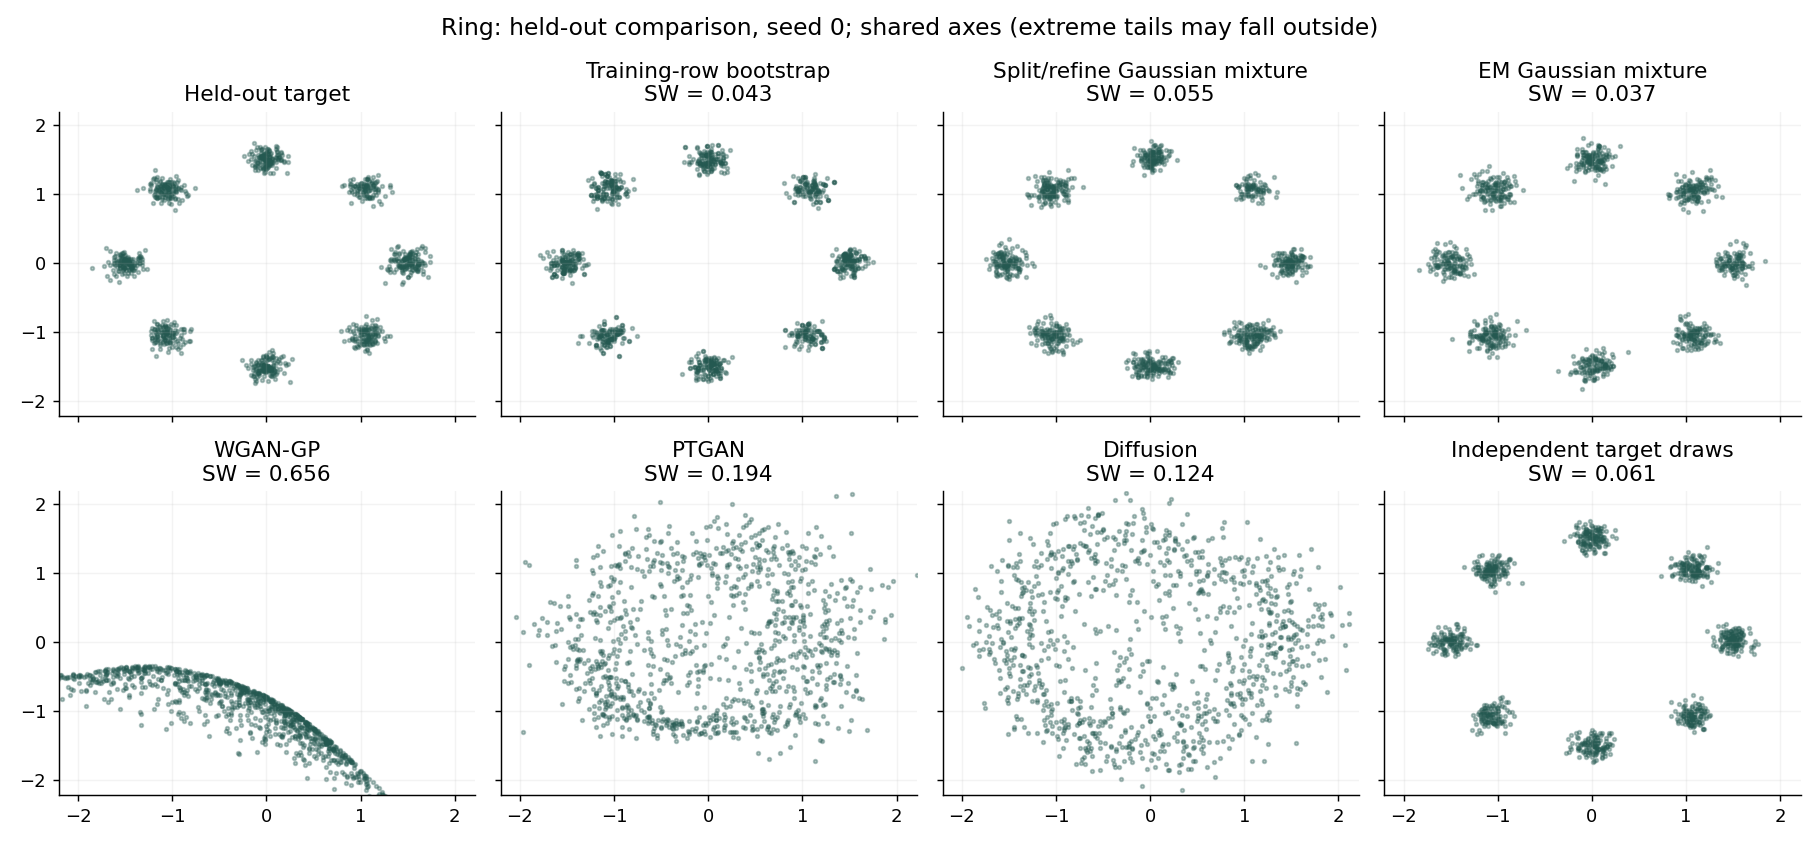

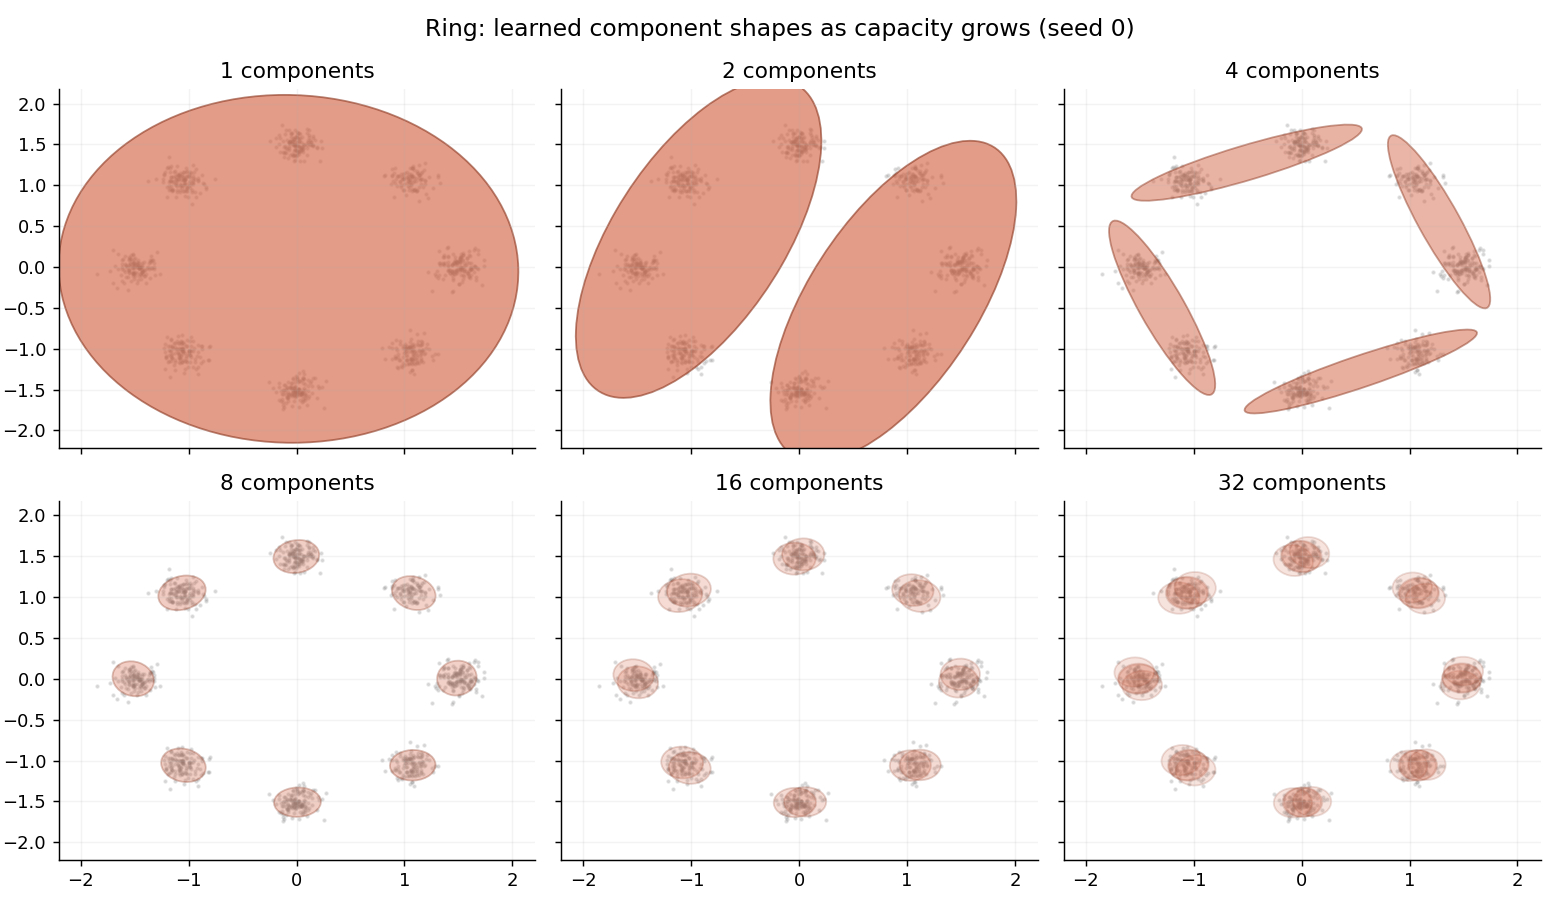

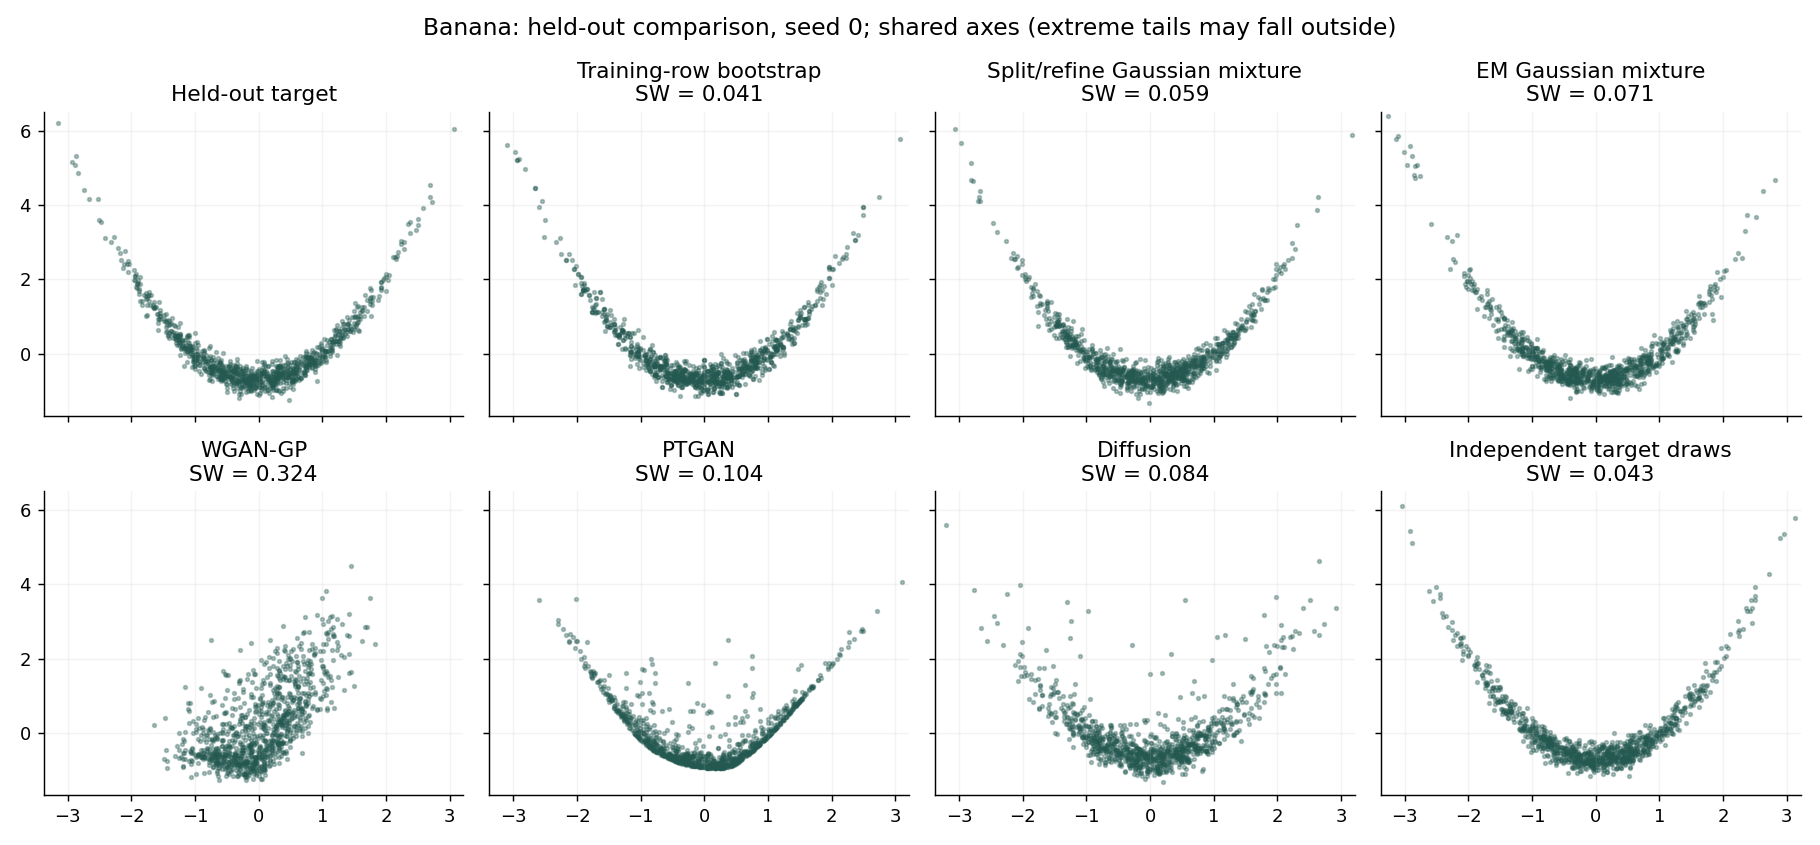

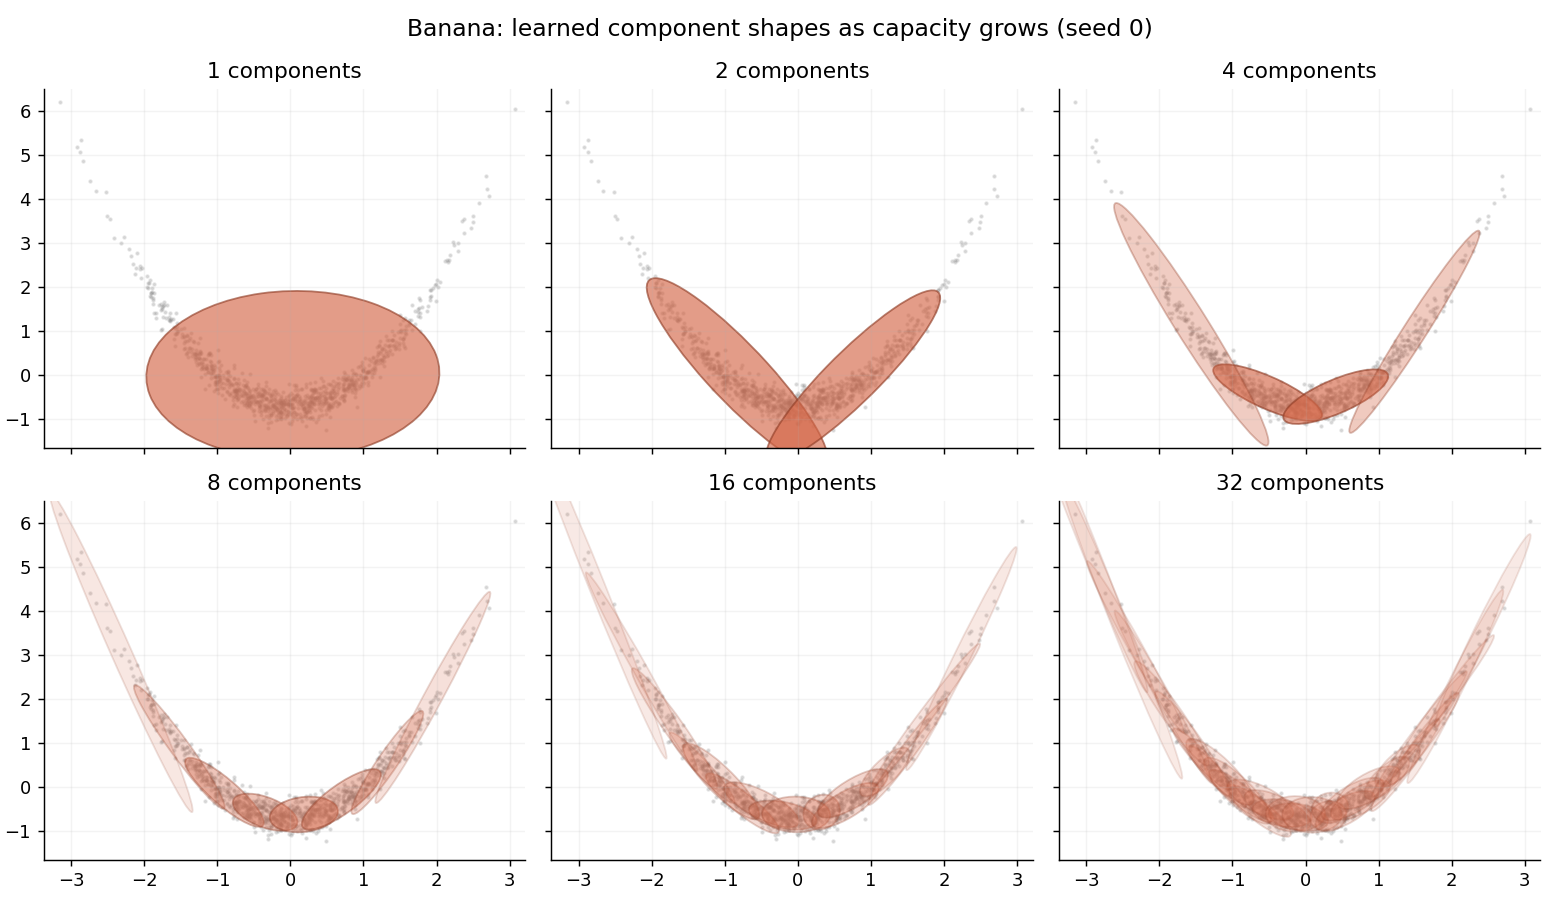

In [2]:
for dataset in ['ring', 'banana']:
    display(Image(filename=str(RESULTS / f'{dataset}-comparison.png')))
    display(Image(filename=str(RESULTS / f'{dataset}-capacity.png')))


The ellipses are component footprints at two standard deviations, not a
jointly calibrated confidence set or a rendered surface. Their opacity is
only a plotting aid; it is not part of the probability model. All sample
panels use the same axes within an example; extreme tails can fall outside
those axes. Numeric diagnostics use all rows.

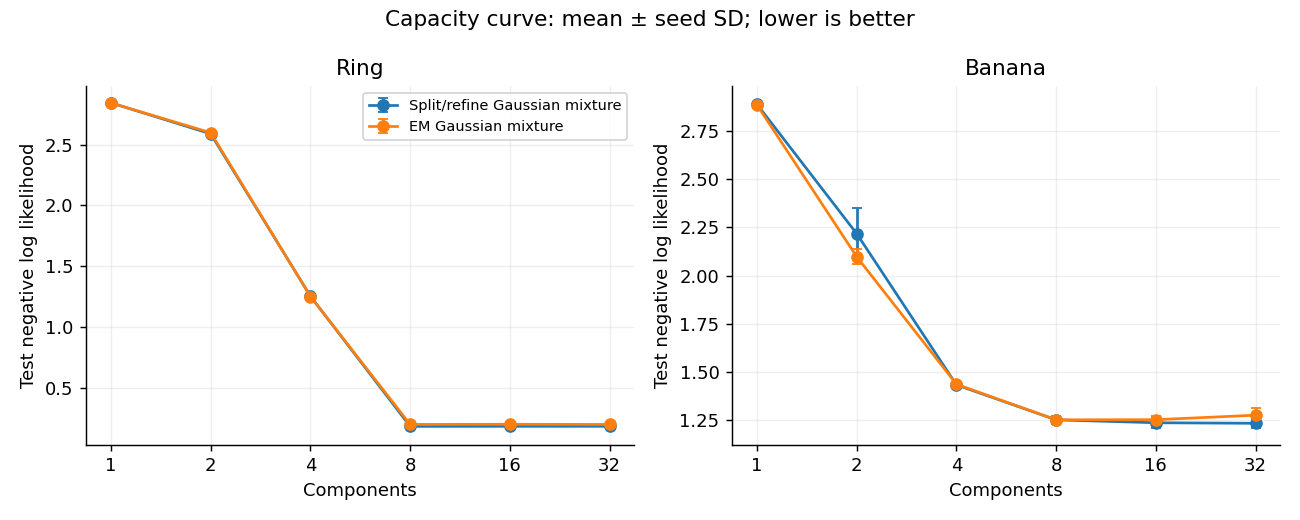

### Selected component counts and test density scores

,dataset,seed,method,k,test_nll
2,ring,0,split_adam,8.0,0.169679
3,ring,0,em_gmm,8.0,0.185579
9,ring,1,split_adam,16.0,0.193040
10,ring,1,em_gmm,8.0,0.211526
16,ring,2,split_adam,32.0,0.201284
17,ring,2,em_gmm,8.0,0.213483
23,banana,0,split_adam,16.0,1.216183
24,banana,0,em_gmm,16.0,1.235529
30,banana,1,split_adam,32.0,1.224469
31,banana,1,em_gmm,16.0,1.251676


### Ring coverage and off-mode mass

,mode_coverage,off_mode_fraction
method,,
bootstrap,8.0,0.0114
diffusion,8.0,0.7253
em_gmm,8.0,0.0296
fresh_target_draws,8.0,0.0085
ptgan,8.0,0.7617
split_adam,8.0,0.0133
wgan,2.0,0.9567


In [3]:
display(Image(filename=str(RESULTS / 'capacity-nll.png')))
display(Markdown('### Selected component counts and test density scores'))
display(rows[rows.method.isin(['split_adam','em_gmm'])][['dataset','seed','method','k','test_nll']])
display(Markdown('### Ring coverage and off-mode mass'))
display(rows[rows.dataset.eq('ring')].groupby('method')[['mode_coverage','off_mode_fraction']].mean().round(4))


## Lalonde: support and inferential targets

The first pilot reuses Trex's transformer: binary columns are rounded and
nonnegative columns are clipped after generation. That is convenient for a
common comparison, but continuous Gaussian likelihood is **not** a valid
mixed-data likelihood for a table with category indicators and exact zeros.
Rounding does not enforce mutually exclusive category combinations; clipping
can create spurious zero masses; age and education need not be integers.

The table below therefore measures zero-mass errors as well as mean earnings.
The adjusted treatment coefficient is the coefficient of `t` in OLS for
`re78` controlling age, education and the four demographic indicators. It is
a **descriptive association** in a generated table, compared with the held-out
sample—not a known causal target, treatment-effect recovery, or an inference
coverage result. With only 89 test rows, this diagnostic is especially noisy.
A simulator requires separate causal structure if it is to generate
counterfactuals or test identification and estimator coverage.

In [4]:
cols = ['sliced_wasserstein','earnings_zero_rate_mae','re78_mean_abs_error','adjusted_association_abs_error']
display(rows[rows.dataset.eq('lalonde')].groupby('method')[cols].agg(['mean','std']).round(3))


sliced_wasserstein        earnings_zero_rate_mae         \
                         mean    std                   mean    std   
method                                                               
bootstrap               0.186  0.038                  0.064  0.027   
diffusion               0.410  0.353                  0.357  0.018   
em_gmm                  0.191  0.044                  0.338  0.028   
ptgan                   0.278  0.018                  0.502  0.047   
split_adam              0.155  0.015                  0.332  0.016   
wgan                    0.695  0.099                  0.479  0.227   

           re78_mean_abs_error           adjusted_association_abs_error  \
                          mean       std                           mean   
method                                                                    
bootstrap              389.105    60.150                       1661.674   
diffusion             1347.353   398.677                        688.516   
em_gmm                 971.202   225.013                        660.844   
ptgan                  503.205   459.808                       5771.243   
split_adam             408.855   348.333                        928.493   
wgan                  4535.796  1012.261                       2140.931   

                      
                 std  
method                
bootstrap   2341.682  
diffusion    435.586  
em_gmm       668.344  
ptgan       2342.185  
split_adam   484.507  
wgan        1137.906

## What to build next

The promising target is a compact, inspectable simulator with cheap sampling
and conditional generation. Gaussian mixtures already have analytic
continuous conditional distributions: observing some coordinates updates
component probabilities and yields conditional Gaussian means and Schur-
complement covariances. This is useful for imputation, but conditioning is
not intervention, and conditional sampling is not implemented in this pilot.

Before a public Trex API, compare fixed-K EM, adaptive EM and adaptive Adam
on time to held-out accuracy. Add residual-directed splitting, pruning, and
low-rank-plus-diagonal covariances only when they improve that trade-off.
Mixed tables need Bernoulli/categorical component factors and hurdle models
for exact zero versus positive earnings, together with explicit support
constraints. These are more substantive extensions than renaming a GMM.

The prototype passed six tests: independent SciPy log-density agreement,
mixture moment preservation under splitting, sampling/reproducibility,
finite-difference covariance gradients, bimodal fitting, and input validation.
This is not a full Trex test-suite result. Source lives in
`benchmarks/gaussian_tabular/`; rerun commands and limitations are in its README.
The existing package API and policy-CATE PR are unchanged.

### References

- [Trex tabular generators](https://github.com/apoorvalal/trex/blob/main/trex/simdgp.py)
- [gsplat](https://jmlr.org/papers/v26/24-1476.html): differentiable Gaussian image rendering, the representation inspiration rather than a tabular likelihood implementation.
- [Lalonde replication inputs](https://github.com/evanmunro/dswgan-paper).
- [scikit-learn Gaussian mixture reference](https://scikit-learn.org/stable/modules/mixture.html).


## Source and results

[Experiment source and result summaries](https://github.com/apoorvalal/trex/tree/experiment/gaussian-tabular-2026-09-23/benchmarks/gaussian_tabular) · [Executed notebook](https://github.com/apoorvalal/trex/tree/experiment/gaussian-tabular-2026-09-23/nb/gaussian_tabular_pilot.ipynb)

The experiment lives on a separate Trex branch and leaves the public package
API unchanged.
